In [1]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.linear_model import LinearRegression

# Διάβασμα δεδομένων 
data = pd.read_csv('close_prices.csv')

In [2]:
data.head()

,Date,Close Price
0,2024-11-13,225.12
1,2024-11-12,224.23
2,2024-11-11,224.23
3,2024-11-08,226.96
4,2024-11-07,227.48


In [3]:
print(data.describe())

       Close Price
count  6300.000000
mean    174.385962
std     146.888554
min      13.120000
25%      78.970000
50%     139.415000
75%     203.407500
max     702.100000


In [4]:
data.isnull()

,Date,Close Price
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
6295,False,False
6296,False,False
6297,False,False
6298,False,False


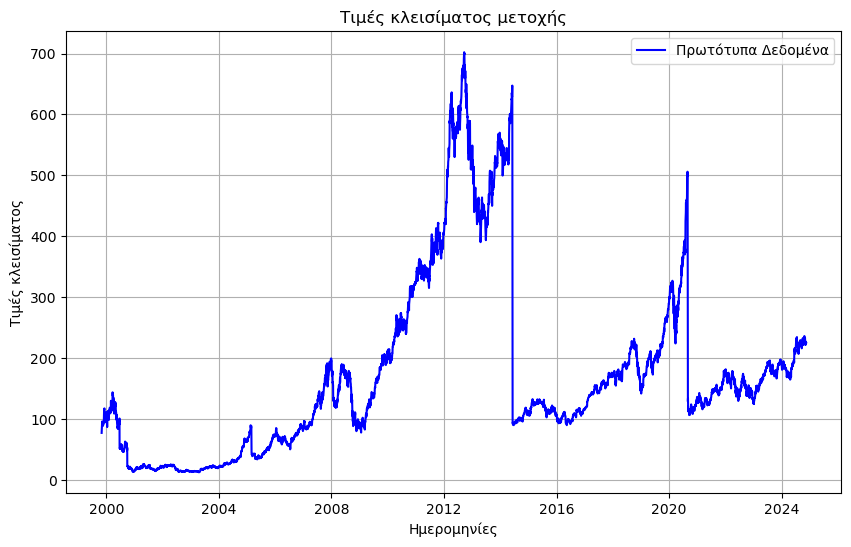

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(data.index, data["Close Price"], label='Πρωτότυπα Δεδομένα', color='b')
plt.title('Τιμές κλεισίματος μετοχής')
plt.xlabel('Ημερομηνίες')
plt.ylabel('Τιμές κλεισίματος')
plt.legend()
plt.grid(True)

plt.show()

In [25]:
from scipy.ndimage import gaussian_filter1d

# εφαρμογή Gaussian smoothing στις τιμές κλεισίματος
smoothed_data = gaussian_filter1d(data["Close Price"], sigma=6)

In [26]:
# δημιουργία στήλης με τις Smoothed τιμές
data["Smoothed Close Price"] = smoothed_data

print(data.head())

        Date  Close Price  Smoothed Close Price
0 2024-11-13       225.12            225.405344
1 2024-11-12       224.23            225.466487
2 2024-11-11       224.23            225.589532
3 2024-11-08       226.96            225.775824
4 2024-11-07       227.48            226.026544


In [27]:
data.to_csv("Smoothed_Close_Prices.csv", index=False)

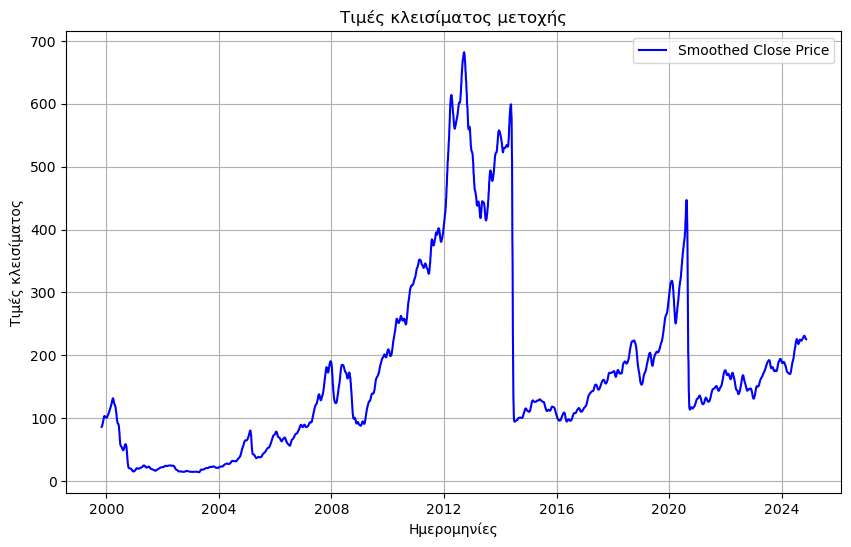

In [28]:
data['Date'] =  pd.to_datetime(data['Date'])

# Plot
plt.figure(figsize=(10, 6))
plt.plot(data['Date'], data['Smoothed Close Price'], label='Smoothed Close Price', color='b')

# Adding titles and labels
plt.title('Τιμές κλεισίματος μετοχής')
plt.xlabel('Ημερομηνίες')
plt.ylabel('Τιμές κλεισίματος')
plt.legend()
plt.grid(True)

plt.show()

In [7]:
import numpy as np

# Υπολογισμός του εύρους
range_of_data = 702.100000 - 13.120000

print("Το εύρος των δεδομένων είναι:", range_of_data)

Το εύρος των δεδομένων είναι: 688.98


In [19]:
import pandas as pd

# Επιλογή της στήλης 'Close Price' 
prices = data['Close Price']

std_close = prices.std()   # Τυπική απόκλιση
variance = prices.var() #διακύμανση

print("Η διακύμανση είναι:", variance)
print("Η τυπική απόκλιση είναι:", std_close)

Η διακύμανση είναι: 21576.247418349434
Η τυπική απόκλιση είναι: 146.88855441575234


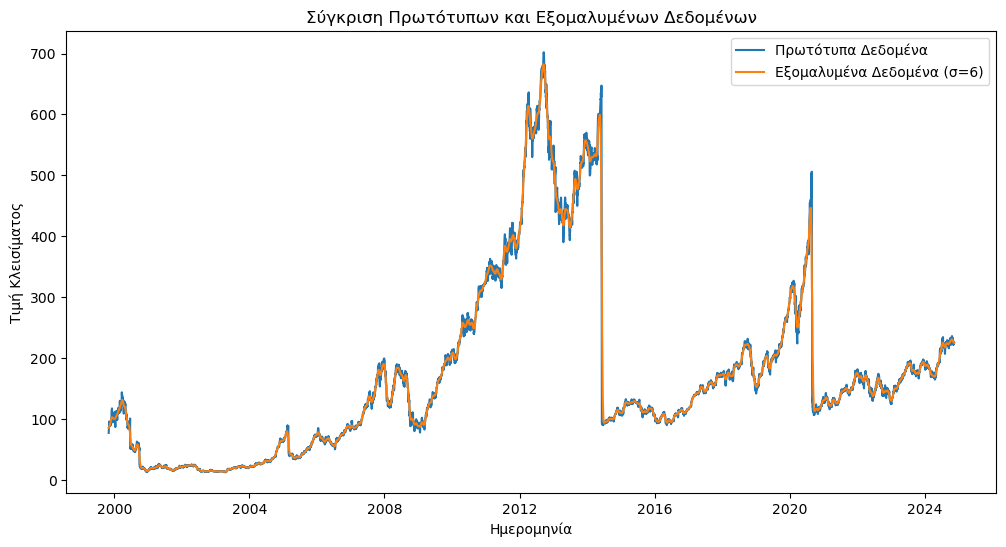

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# εχουν ήδη φορτωθει τα δεδομένα στο DataFrame 'data'

# Εφαρμογή του Gaussian φίλτρου
smoothed_data = gaussian_filter1d(data["Close Price"], sigma=6)

# Δημιουργία γραφήματος
plt.figure(figsize=(12, 6))

# Πρωτότυπα δεδομένα
plt.plot(data.index, data["Close Price"], label='Πρωτότυπα Δεδομένα')

# Εξομαλυμένα δεδομένα
plt.plot(data.index, smoothed_data, label='Εξομαλυμένα Δεδομένα (σ=6)')

# Προσθήκη τίτλου και λεζάντας
plt.title('Σύγκριση Πρωτότυπων και Εξομαλυμένων Δεδομένων')
plt.xlabel('Ημερομηνία')
plt.ylabel('Τιμή Κλεισίματος')
plt.legend()

# Εμφάνιση του γραφήματος
plt.show()

C:\Users\evage\AppData\Local\Temp\ipykernel_13324\4026801067.py:10: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  data_grouped = data.groupby(pd.Grouper(freq='Y'))


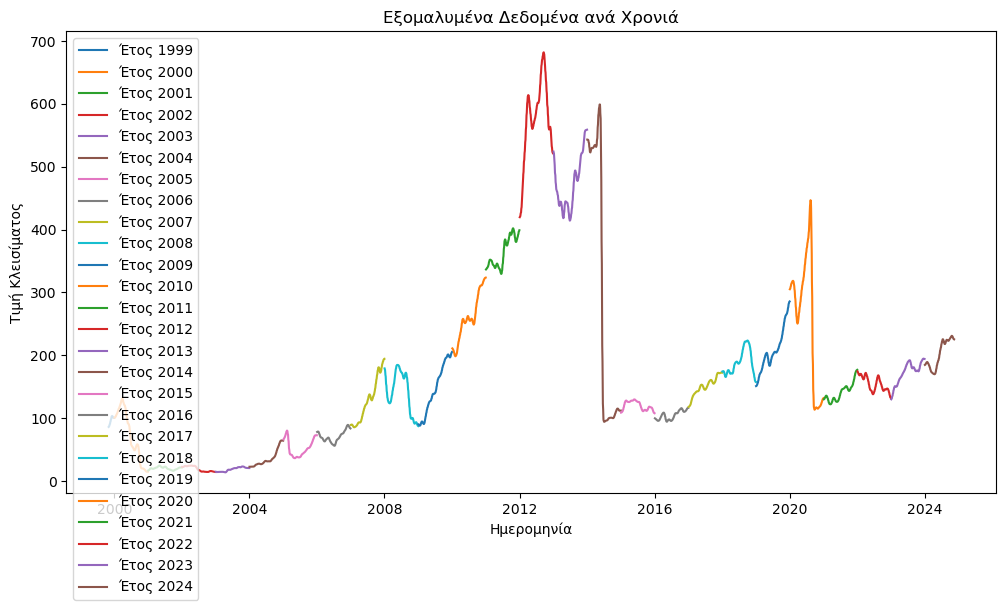

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Ας υποθέσουμε ότι το DataFrame 'data' έχει μια στήλη 'Date' με ημερομηνίες

# Ομαδοποίηση των δεδομένων ανά έτος
data.index = pd.to_datetime(data['Date'])  # Μετατροπή της στήλης 'Date' σε datetime
data_grouped = data.groupby(pd.Grouper(freq='Y'))

# Δημιουργία γραφήματος
plt.figure(figsize=(12, 6))

for year, group in data_grouped:
    smoothed_data = gaussian_filter1d(group['Close Price'], sigma=6)
    plt.plot(group.index, smoothed_data, label=f'Έτος {year.year}')

# Προσθήκη τίτλου και λεζάντας
plt.title('Εξομαλυμένα Δεδομένα ανά Χρονιά')
plt.xlabel('Ημερομηνία')
plt.ylabel('Τιμή Κλεισίματος')
plt.legend()

# Εμφάνιση του γραφήματος
plt.show()